# Auto Email / Support Ticket Categorizer

A lightweight NLP classification system that reads an incoming support email/ticket
and predicts which department should handle it: **Billing**, **Technical**, **HR**, or **General**.

**Pipeline:** Text → Preprocessing → TF-IDF Vectorizer → Multinomial Naive Bayes → Predicted Category


In [1]:
import re
import string

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

RANDOM_STATE = 42
CONFIDENCE_THRESHOLD = 0.60
URGENT_KEYWORDS = ["urgent", "emergency", "down", "not working", "critical", "asap"]


## 1. Load the Dataset

We use a dummy dataset of 92 realistic support tickets, roughly balanced across the four categories.

In [2]:
df = pd.read_csv("../data/tickets.csv")
print(df.shape)
df.head(10)

(92, 3)


,subject,body,category
0,Invoice not generated,My invoice for last month has still not been g...,Billing
1,Charged twice this month,I was charged twice for my subscription this b...,Billing
2,Refund still pending,I requested a refund two weeks ago and it stil...,Billing
3,Update billing information,How can I update my billing information and ca...,Billing
4,Wrong amount charged,The amount charged to my card does not match t...,Billing
5,Subscription renewal question,Why was I billed for a subscription I already ...,Billing
6,Need a copy of my invoice,Can you please send me a copy of my invoice fo...,Billing
7,Payment failed but money deducted,My payment failed on the website but the money...,Billing
8,Upgrade plan billing query,"If I upgrade my plan mid-cycle, how will the p...",Billing
9,Tax invoice request,I need a GST tax invoice for my last purchase ...,Billing


In [3]:
df["category"].value_counts()

category
Billing      23
Technical    23
HR           23
General      23
Name: count, dtype: int64

## 2. Preprocessing

Steps and why we use them:
- **Lowercasing** – so "Invoice" and "invoice" are treated as the same word.
- **Punctuation removal** – punctuation adds noise and extra vocabulary without much classification signal here.
- **Whitespace collapsing** – keeps tokens clean after punctuation is stripped.
- **Missing value handling** – empty subject/body fields are filled with `""` so the pipeline never crashes on `NaN`.
- **Combining subject + body** – the subject line is often a strong, concise signal, so we keep it together with the body rather than discarding it.

We intentionally skip stopword removal/stemming as a separate manual step — TF-IDF's own `stop_words` handling already down-weights very common words, and with such a small dataset aggressive preprocessing risks removing useful signal (e.g. "not working").


In [4]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df["text"] = df["subject"] + " " + df["body"]
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Invoice not generated My invoice for last mont...,invoice not generated my invoice for last mont...
1,Charged twice this month I was charged twice f...,charged twice this month i was charged twice f...
2,Refund still pending I requested a refund two ...,refund still pending i requested a refund two ...
3,Update billing information How can I update my...,update billing information how can i update my...
4,Wrong amount charged The amount charged to my ...,wrong amount charged the amount charged to my ...


## 3. Train/Test Split

An 80/20 split, stratified by category so each class is proportionally represented in both sets, with a fixed `random_state` for reproducibility.


In [5]:
X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 73
Test size: 19


## 4. Feature Extraction — TF-IDF

Raw text cannot be fed directly into scikit-learn classifiers; they require numeric input. **TF-IDF (Term Frequency – Inverse Document Frequency)** converts each ticket into a numeric vector where each dimension corresponds to a word, weighted by how important that word is to a specific ticket relative to the whole dataset. Common words that appear everywhere (e.g. "please", "the") get a low weight, while words distinctive of a category (e.g. "invoice", "crashes", "payslip") get a higher weight. This makes TF-IDF well suited to short, keyword-driven text like support tickets.

**Important:** the vectorizer is fit **only on the training data** and then used to transform the test data, to avoid data leakage.


In [6]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix shape:", X_train_tfidf.shape)

Vocabulary size: 313
Train matrix shape: (73, 313)


## 5. Model — Multinomial Naive Bayes

Multinomial Naive Bayes is a strong baseline for text classification because:
1. It works well with sparse, high-dimensional TF-IDF features.
2. It trains quickly and needs relatively little data compared to more complex models.
3. Its "naive" independence assumption between words tends to work fine in practice for bag-of-words style problems like this one.


In [7]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print("Model trained.")

Model trained.


## 6. Model Evaluation

In [8]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7895

Classification Report:
              precision    recall  f1-score   support

     Billing       0.71      1.00      0.83         5
     General       0.67      1.00      0.80         4
          HR       1.00      0.40      0.57         5
   Technical       1.00      0.80      0.89         5

    accuracy                           0.79        19
   macro avg       0.85      0.80      0.77        19
weighted avg       0.85      0.79      0.77        19



**Interpreting the metrics for support-ticket routing:**
- **Precision** for a category (e.g. Billing) tells us: of all tickets the model *predicted* as Billing, how many were *actually* Billing. High precision means we rarely misroute other tickets into Billing.
- **Recall** for a category (e.g. Technical) tells us: of all *actual* Technical tickets, how many the model *successfully caught*. High recall means very few real Technical tickets slip through to the wrong queue.
- **F1-score** balances precision and recall into a single number, useful when we care about both false positives and false negatives.

Looking at the report above, categories with clearly distinctive vocabulary (like Billing and Technical) tend to score well, while **HR sometimes gets confused with Billing/General** — likely because tickets in this dataset share overlapping phrases like "last month" or "download". This is a realistic limitation given the small dataset size, and is exactly the kind of case the human-review fallback (Section 9) is designed to catch.


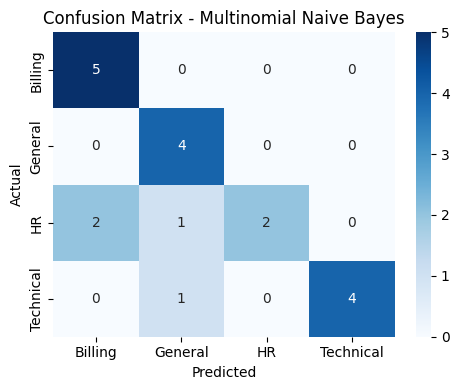

In [9]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 7. Optional Comparison — Logistic Regression

Just to see how a simple linear model compares against Naive Bayes on the same TF-IDF features.


In [10]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}\n")
print(classification_report(y_test, lr_pred, zero_division=0))

Logistic Regression Accuracy: 0.8947



              precision    recall  f1-score   support

     Billing       0.83      1.00      0.91         5
     General       1.00      1.00      1.00         4
          HR       0.80      0.80      0.80         5
   Technical       1.00      0.80      0.89         5

    accuracy                           0.89        19
   macro avg       0.91      0.90      0.90        19
weighted avg       0.90      0.89      0.89        19



## 8. Priority Tagging (rule-based, separate from the ML model)

A simple keyword-based rule flags a ticket as `URGENT` if it contains words like *urgent, emergency, down, not working, critical, asap* — otherwise `NORMAL`. This is deliberately kept independent of the ML category classifier, since urgency and department are two different concerns.


In [11]:
def get_priority(raw_text: str) -> str:
    text = raw_text.lower()
    for keyword in URGENT_KEYWORDS:
        if keyword in text:
            return "URGENT"
    return "NORMAL"

print(get_priority("The server is down and this is urgent"))
print(get_priority("How do I update my billing info?"))

URGENT
NORMAL


## 9. Real-Time Prediction Function with Confidence & Human-Review Threshold

`predict_ticket(subject, body)` combines subject + body, cleans the text, transforms it with the already-fitted TF-IDF vectorizer, predicts a category, computes a confidence score using `predict_proba()`, and applies a **60% confidence threshold**: if the model's top confidence is below that, the ticket is routed to `"Needs Human Review"` instead of being auto-assigned. This matters in a real support system because a wrong auto-routing decision can delay resolution and frustrate a customer — it's safer to have a human quickly triage low-confidence tickets than to blindly trust an uncertain prediction.


In [12]:
def predict_ticket(subject: str, body: str) -> dict:
    raw_text = f"{subject} {body}"
    cleaned = clean_text(raw_text)
    vec = vectorizer.transform([cleaned])

    probabilities = model.predict_proba(vec)[0]
    predicted_category = model.classes_[probabilities.argmax()]
    confidence = float(probabilities.max())

    if confidence < CONFIDENCE_THRESHOLD:
        final_decision = "Needs Human Review"
    else:
        final_decision = predicted_category

    priority = get_priority(raw_text)

    return {
        "category": predicted_category,
        "confidence": round(confidence, 4),
        "priority": priority,
        "final_decision": final_decision,
    }

# quick sanity check
predict_ticket("Refund not received", "I still have not received my refund from last week.")

{'category': np.str_('Billing'),
 'confidence': 0.507,
 'priority': 'NORMAL',
 'final_decision': 'Needs Human Review'}

## 10. Testing on New, Unseen Tickets

Five+ brand-new tickets that were **not** part of the training/test data, covering all four categories.


In [13]:
new_tickets = [
    ("Double charge on my card", "My credit card was charged twice for this month's subscription, please refund."),
    ("Server is down", "Our production server is down and the API is not working at all, this is critical."),
    ("Payslip download issue", "I am unable to download my payslip from the HR portal for last month."),
    ("General question about pricing", "Hi, I would like to know more about your pricing plans and what they include."),
    ("Password reset link broken", "I clicked the reset password link but it says the link has expired."),
    ("Question about office holidays", "Can you tell me the list of official holidays for this year?"),
]

for subject, body in new_tickets:
    result = predict_ticket(subject, body)
    print(f"Subject: {subject}")
    print(f"Body:    {body}")
    print(f"Prediction:     {result['category']}")
    print(f"Confidence:     {result['confidence']*100:.1f}%")
    print(f"Priority:       {result['priority']}")
    print(f"Final Decision: {result['final_decision']}")
    print("-" * 60)

Subject: Double charge on my card
Body:    My credit card was charged twice for this month's subscription, please refund.
Prediction:     Billing
Confidence:     61.3%
Priority:       NORMAL
Final Decision: Billing
------------------------------------------------------------
Subject: Server is down
Body:    Our production server is down and the API is not working at all, this is critical.
Prediction:     Technical
Confidence:     31.4%
Priority:       URGENT
Final Decision: Needs Human Review
------------------------------------------------------------
Subject: Payslip download issue
Body:    I am unable to download my payslip from the HR portal for last month.
Prediction:     Billing
Confidence:     32.7%
Priority:       URGENT
Final Decision: Needs Human Review
------------------------------------------------------------
Subject: General question about pricing
Body:    Hi, I would like to know more about your pricing plans and what they include.
Prediction:     General
Confidence:   

## 11. Summary

- The **TF-IDF + Multinomial Naive Bayes** pipeline achieves a reasonable accuracy on this small dummy dataset, with strong performance on Billing/Technical/General and more confusion around HR (its vocabulary overlaps with Billing/General in several tickets).
- The **60% confidence threshold** correctly routes several of the new, harder unseen tickets to `"Needs Human Review"` rather than confidently mis-assigning them — this is the intended behavior of the safety fallback.
- A **Logistic Regression** comparison shows a modest accuracy improvement over Naive Bayes on this dataset, which is common for small TF-IDF-based text classification tasks.
- With a larger, more diverse real-world ticket dataset, both accuracy and confidence calibration would be expected to improve further.
